# SegmentViewer GL — WebGL2 demo

**Performance characteristics:**
- Segment track: GPU instanced rendering, 1 draw call/group, zero CPU on pan/zoom
- Heatmap track: R8 texture, handles 10 k+ individuals at 60 fps
- Pan/zoom: uniform-only updates — no buffer uploads during interaction
- Culling: sorted attribute-pointer offset skips non-visible instances

In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import pickle
from collections import OrderedDict
from geneinfo.widget import Tracks
from vscodenb import set_vscode_theme
set_vscode_theme()

rng = np.random.default_rng(42)


## Chromosome and gene info

In [2]:
from geneinfo.genelist import GeneList as glist
from geneinfo.genelist import GeneListCollection
sheet = GeneListCollection(google_sheet='1JSjSLuto3jqdEnnG7JqzeC_1pUZw76n7XueVAYrUOpk')

from geneinfo.coords import chromosome_lengths
chrom_sizes = dict(chromosome_lengths(assembly='hg38'))

## Generate synthetic quantitative data for chr1

In [3]:

quant_rows = []
for chrom, csz in chrom_sizes.items():
    n_points = 2000
    positions = np.sort(rng.integers(0, csz, n_points))
    fst = np.abs(rng.normal(0.05, 0.08, n_points)).clip(0, 1)
    rate = np.cumsum(rng.normal(0, 0.3, n_points))
    rate = (rate - rate.min()) / (rate.max() - rate.min()) * 5 + 0.5
    mid = np.cumsum(rng.normal(0, 0.15, n_points))
    eig = np.sin(positions / 1e7 * 2 * np.pi) + rng.normal(0, 0.2, n_points)
    ci_lo = mid - rng.exponential(0.3, n_points)
    ci_hi = mid + rng.exponential(0.3, n_points) + 10
    depth = rng.poisson(30, n_points).astype(float)

    for pop in ['AFR', 'EUR']:
        noise = rng.normal(0, 0.02, n_points)
        for i in range(n_points):
            quant_rows.append({
                'chrom': chrom, 'pos': int(positions[i]),
                'fst': float(fst[i] + noise[i]),
                'rate': float(rate[i] + noise[i] * 10) + (0.5 if pop == 'EUR' else 0),
                'eig': float(eig[i] + noise[i]),
                'ci_lo': float(ci_lo[i]), 'ci_hi': float(ci_hi[i]),
                'depth': float(depth[i] + rng.normal(0, 3)),
                'pop': pop,
            })

qdf = pd.DataFrame(quant_rows)
print(f'{len(qdf):,} data points')

96,000 data points


In [8]:
gene_view = (
    Tracks(chrom_sizes)
    .add_scatter_track(
        qdf, 'GWAS -log10(p)', x='pos', y='fst', group_by='pop', tip_fmt=False,
    )
    .add_gene_track(assembly='hg38',
#                                   height=100,
                                   label_padding=50000
    )
)
gene_view.pan_speed = 2
gene_view

## Archaic introgression segments

In [9]:
# Load metadata
meta = pq.ParquetFile('/Users/kmt/davide_segments_v2/dims/metadata.parquet').read().to_pandas()
meta.reg.unique()

<ArrowStringArray>
['EAS', 'OCE', 'EUR', 'AMR', 'SAS', 'AFR', 'MID']
Length: 7, dtype: str

In [10]:

# # subset
# # subset_regs = ['AFR', 'EUR', 'EAS', 'SAS', 'MID', 'OCE', 'AMR']
# subset_regs = ['EUR', 'EAS', 'OCE']
# subset_meta = meta[(meta['sex'] == 'F') & meta['reg'].isin(subset_regs)].groupby('reg').head(1000)

subset_meta = meta[meta['reg'].isin(['EUR', 'EAS', 'OCE'])]
# # all
# subset_meta = meta
# subset_meta.head()

subset_meta.ind.unique().size
# Read fragment parquet files (one per individual)
frames = []
for ind in subset_meta['ind']:
    fp = Path(f'/Users/kmt/davide_segments_v2/fragments/phase_state=phased/ind={ind}/0.parquet')
    if fp.exists() and fp.stat().st_size:
        data = pq.ParquetFile(fp).read()
        frames.append(pq.ParquetFile(fp).read().to_pandas())

segments = pd.concat(frames, ignore_index=True)
segments['chrom'] = 'chr' + segments['chrom'].astype(str)
#segments = segments[segments['chrom'] == 'chr1']
segments = segments.merge(meta[['ind', 'reg', 'pop', 'sex']], on='ind', how='left')

#chrom_sizes = {'chr1': 248_956_422}

print(f'{len(segments):,} segments from {segments["ind"].nunique()} individuals')
print(f'Mean length: {(segments["end"] - segments["start"]).mean():,.0f} bp')
print(f'Regions: {dict(segments.groupby("reg")["ind"].nunique())}')
print(f'Ancestries: {sorted(segments["ancestry"].unique())}')

# # Prepare heatmap input: needs chrom, start, end, sample (individual), pop (group)
# hm_df = segments[['chrom', 'start', 'end', 'ind', 'reg']].rename(
#     columns={'ind': 'sample', 'reg': 'pop'}
# )

region_colors={'AFR': "#d80019", 'EUR': "#0067cf", 'SAS': "#7e00bd", 'EAS': "#00a75f", 'MID': "#c20098", 'OCE': "#d19300", 'AMR': "#7e4e00"}
ancestry_colors={'Altai': 'green', 'Vindija': 'orange', 'Chagyrskaya': 'blue', 'AmbigNean': 'purple', 'Denisova': 'red', 'nonDAVC': 'gray'}


1,968,492 segments from 866 individuals
Mean length: 64,029 bp
Regions: {'EAS': np.int64(302), 'EUR': np.int64(304), 'OCE': np.int64(260)}
Ancestries: ['Altai', 'AmbigNean', 'Ambiguous', 'Chagyrskaya', 'Denisova', 'Vindija', 'nonDAVC']


In [11]:
segments.to_parquet('segments.parquet')

In [12]:
viewer = (
    Tracks(chrom_sizes)
    .add_segment_track(
        segments.loc[segments['reg'] == 'EUR'], 'EUR', group_by='ancestry', individual_col='ind',
        color_map=ancestry_colors, tip_fmt=False, stack=True,
        height=60, density_windows=(512, 2048, 8192),
    )   
    .add_segment_track(
        segments.loc[segments['reg'] == 'SAS'], 'SAS', group_by='ancestry', individual_col='ind',
        color_map=ancestry_colors, tip_fmt=False, stack=True,
        height=60, density_windows=(512, 2048, 8192),
    )  
    .add_segment_track(
        segments.loc[segments['reg'] == 'EAS'], 'EAS', group_by='ancestry', individual_col='ind',
        color_map=ancestry_colors, tip_fmt=False, stack=True,
        height=60, density_windows=(512, 2048, 8192),
    )   
    .add_segment_track(
        segments.loc[segments['reg'] == 'MID'], 'MID', group_by='ancestry', individual_col='ind',
        color_map=ancestry_colors, tip_fmt=False, stack=True,
        height=60, density_windows=(512, 2048, 8192),
    )  
    .add_segment_track(
        segments.loc[segments['reg'] == 'OCE'], 'OCE', group_by='ancestry', individual_col='ind',
        color_map=ancestry_colors, tip_fmt=False, stack=True,
        height=60, density_windows=(512, 2048, 8192),
    )   
    .add_segment_track(
        segments.loc[segments['reg'] == 'AMR'], 'AMR', group_by='ancestry', individual_col='ind',
        color_map=ancestry_colors, tip_fmt=False, stack=True,
        height=60, density_windows=(512, 2048, 8192),
    )  
    .add_gene_track(assembly='hg38', name='Genes', 
                    height = 100, 
                    collapse=True, 
                    # highlight=['LHX8'], highlight_color="#ee55c5",
                    highlight={                                                                   
                        'fill':      sheet.get('cDEG'),                                           
                        'stroke':    ['LRRC40'],                                                     
                        'outline':   ['BRCA1'],                                                   
                        'color':     ['SRSF11'],                                                    
                        'bold':      ['LRRC7', 'LRRC40'],                                           
                        'italic':    ['ANKRD13C'],                                                     
                        'underline': ['CTH'],                                                    
                        'halo':      ['SRSF11'],                                                   
                    },                                                                            
                    # highlight_fill_color    = "#e03a4e",                  
                    # highlight_spine_color   = "#d80ce6",                                          
                    # highlight_outline_color = "#000000",                                          
                    # highlight_label_color   = "#169f4a",                                          
                    # highlight_halo_color    = "#4152CF2F",                                            
                    )
)
viewer

In [13]:
viewer = (
    Tracks(chrom_sizes)
    .add_heatmap_track(
        segments, 'Individual haplotypes',
        individual_col='ind',
            group_col='reg',
            color_map=region_colors,
        # height=390,
        # windows=16384,
        windows=8192,
        tip_fmt=False,
    )
    .add_gene_track(assembly='hg38', name='Genes', 
                    height = 100, 
                    label_padding=10000,
                    # highlight=['LHX8'], highlight_color="#ee55c5",
                    highlight={                                                                   
                        'fill':      sheet.get('cDEG'),                                           
                        'stroke':    ['LRRC40'],                                                     
                        'outline':   ['BRCA1'],                                                   
                        'color':     ['SRSF11'],                                                    
                        'bold':      ['LRRC7', 'LRRC40'],                                           
                        'italic':    ['ANKRD13C'],                                                     
                        'underline': ['CTH'],                                                    
                        'halo':      ['SRSF11'],                                                   
                    },                                                                            
                    # highlight_fill_color    = "#e03a4e",                  
                    # highlight_spine_color   = "#d80ce6",                                          
                    # highlight_outline_color = "#000000",                                          
                    # highlight_label_color   = "#169f4a",                                          
                    # highlight_halo_color    = "#4152CF2F",                                            
                    )
)
viewer

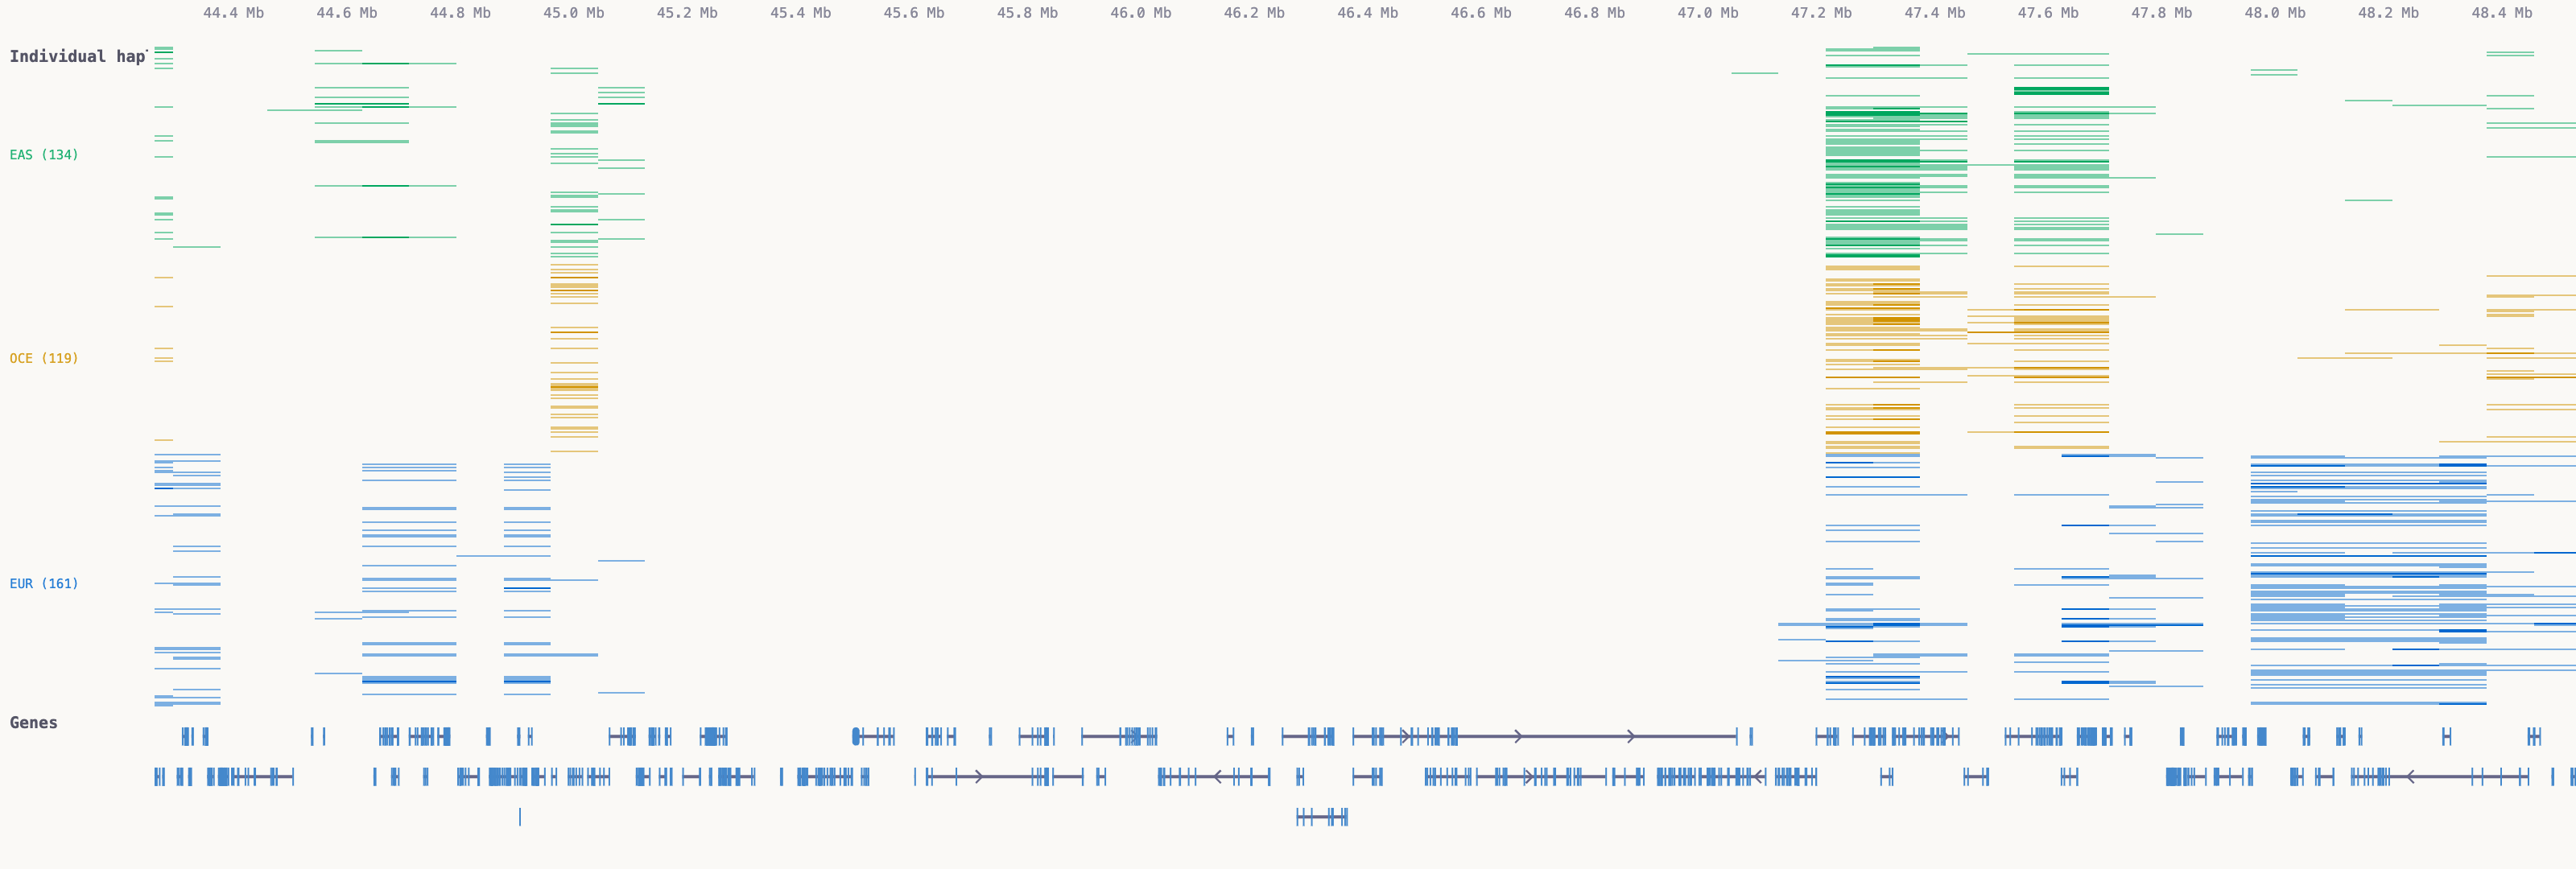

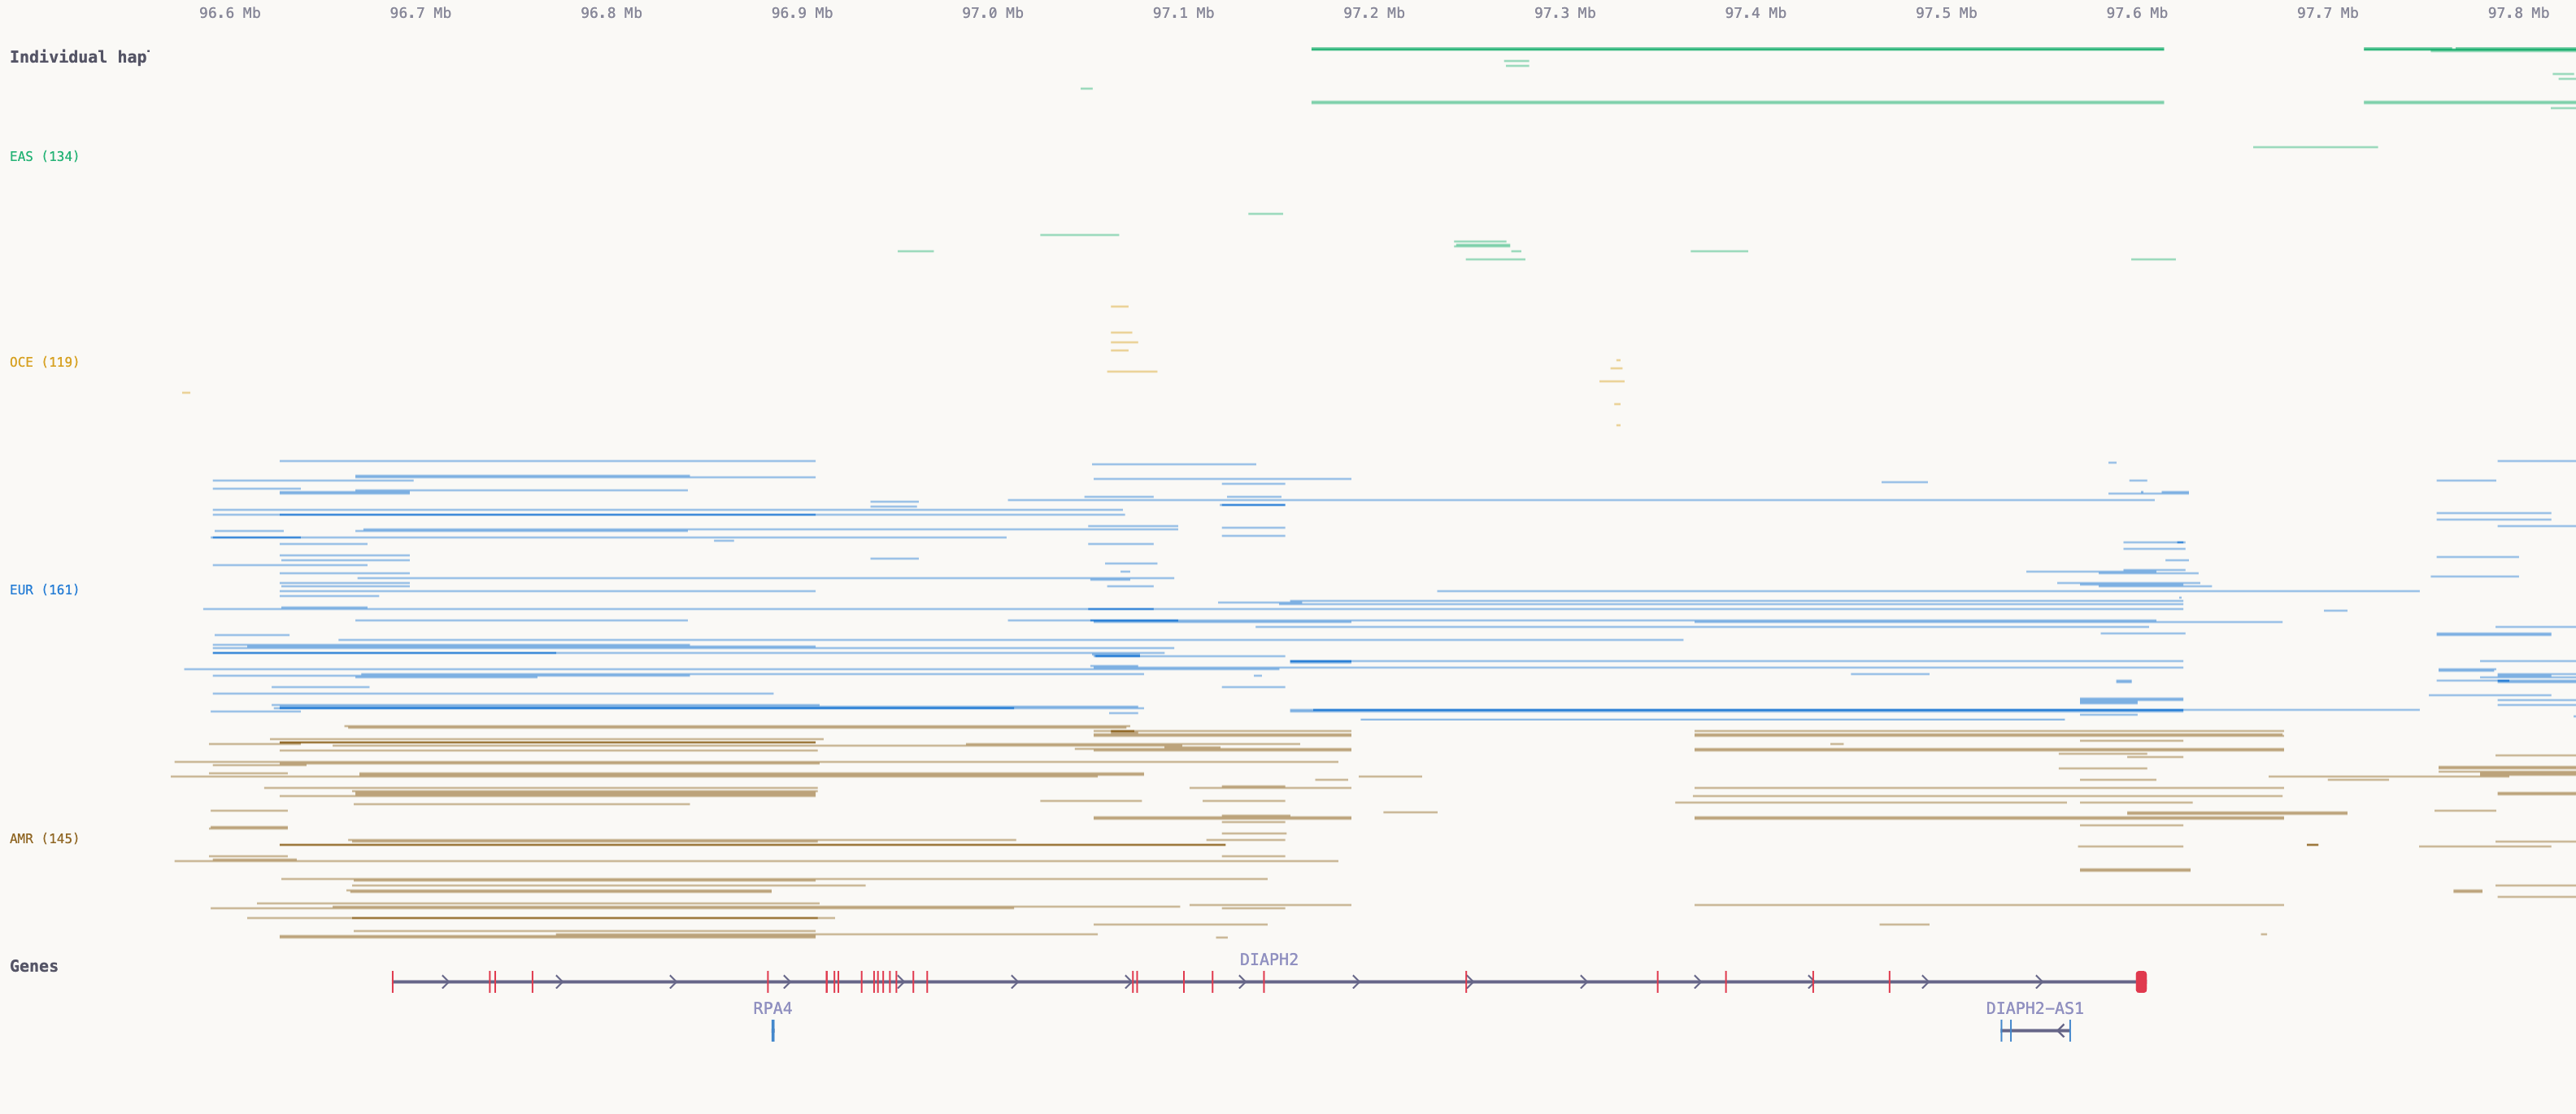

In [5]:
viewer = (
    Tracks(chrom_sizes)
    # .add_segment_track(
    #     segments, 'Introgression by region', group_by='reg', individual_col='ind',
    #     color_map=region_colors, tip_fmt=False,
    #     height=60, density_windows=(512, 2048, 8192),
    # )
    # .add_segment_track(
    #     segments, 'Introgression by ancestry', group_by='ancestry', individual_col='ind',
    #     color_map=region_colors, tip_fmt=False,
    #     height=60, density_windows=(512, 2048, 8192),
    # )
    .add_scatter_track(
        qdf, 'GWAS -log10(p)', x='pos', y='fst', group_by='pop', tip_fmt=False,
        color_map=region_colors, height=60, point_size=2,
    )
    .add_line_track(
        qdf, 'Rec. rate', x='pos', y='rate', group_by='pop',
        step='post', color_map=region_colors, tip_fmt=False,
        height=60,
    )
    .add_fill_track(
        qdf, 'Conf. int. (lo/hi)', x='pos', y_hi='ci_hi', y_lo='ci_lo', group_by='pop',
        color_pos="#ee5555", color_neg="#5567ee", height=60, tip_fmt=False,
    )
    .add_fill_track(
        qdf, 'A/B comp.', x='pos', y='eig', group_by='pop', tip_fmt=False,
        step='post', color_pos='#4488cc', color_neg='#ee5566', height=60,
    )
    .add_histogram_track(
        qdf, 'Seq. depth', x='pos', y='depth', group_by='pop', tip_fmt=False,
        color_map=region_colors, height=60, 
    )
    .add_segment_track(
        segments.loc[segments['reg'] == 'EUR'], 'EUR', group_by='reg', individual_col='ind',
        color_map=region_colors, tip_fmt=False,
        height=60, density_windows=(512, 2048, 8192),
    )
    .add_segment_track(
        segments.loc[segments['reg'] == 'EAS'], 'EAS', group_by='reg', individual_col='ind',
        color_map=region_colors, tip_fmt=False,
        height=60, density_windows=(512, 2048, 8192),
    )
    .add_segment_track(
        segments, 'Introgression by ancestry', group_by='ancestry', individual_col='ind',
        color_map=region_colors, tip_fmt=False, stack=True,
        height=160, density_windows=(512, 2048, 8192),
    )
    .add_gene_track(assembly='hg38', name='Genes', 
                    height = 100, 
                    collapse=True, 
                    # highlight=['LHX8'], highlight_color="#ee55c5",
                    highlight={                                                                   
                        'fill':      ['LRRC7', 'PIN1P1'],                                           
                        'stroke':    ['LRRC40'],                                                     
                        'outline':   ['BRCA1'],                                                   
                        'color':     ['SRSF11'],                                                    
                        'bold':      ['LRRC7', 'LRRC40'],                                           
                        'italic':    ['ANKRD13C'],                                                     
                        'underline': ['CTH'],                                                    
                        'halo':      ['SRSF11'],                                                   
                    },                                                                            
                    # highlight_fill_color    = "#e03a4e",                  
                    # highlight_spine_color   = "#d80ce6",                                          
                    # highlight_outline_color = "#000000",                                          
                    # highlight_label_color   = "#169f4a",                                          
                    # highlight_halo_color    = "#4152CF2F",                                            
                    )
)
#viewer.theme = theme                                      
viewer.zoom_speed = 1.025
viewer

NameError: name 'region_colors' is not defined

In [ ]:
viewer2 = (
    Tracks(chrom_sizes)
    .add_segment_track(
        segments, 'Introgression by region',
        group_by='reg',
        individual_col='ind',
        color_map=region_colors,
        height=90,
        tip_fmt=False,
        density_windows=(512, 2048, 8192),
    )
    .add_heatmap_track(
        hm_df, 'Individual haplotypes',
        individual_col='sample',
            group_col='pop',
            color_map=region_colors,
        height=390,
        # windows=16384,
        windows=5000,
        tip_fmt=False,
    )
)
# viewer2.theme = theme                                      
viewer2.zoom_speed = 1.015
viewer2

In [ ]:
viewer = (
    Tracks(chrom_sizes)
    .add_segment_track(
        segments.loc[segments['reg'] == 'EUR'], 'EUR', group_by='reg', individual_col='ind',
        color_map=region_colors, tip_fmt=False,
        height=60, density_windows=(512, 2048, 8192),
    )
    .add_segment_track(
        segments.loc[segments['reg'] == 'EAS'], 'EAS', group_by='reg', individual_col='ind',
        color_map=region_colors, tip_fmt=False,
        height=60, density_windows=(512, 2048, 8192),
    )
    .add_gene_track(assembly='hg38', name='Genes', collapse=True)
)
viewer

NameError: name 'theme' is not defined

## Summary data, meta-data, gene track

In [ ]:
viewer = (
    Tracks(chrom_sizes)
    .add_segment_track(
        segments, 'Introgression by region', group_by='reg', individual_col='ind',
        color_map=region_colors, tip_fmt=False,
        height=60, density_windows=(512, 2048, 8192),
    )
    .add_segment_track(
        segments, 'Introgression by ancestry', group_by='ancestry', individual_col='ind',
        color_map=region_colors, tip_fmt=False,
        height=60, density_windows=(512, 2048, 8192),
    )
    .add_scatter_track(
        qdf, 'GWAS -log10(p)', x='pos', y='fst', group_by='pop', tip_fmt=False,
        color_map=region_colors, height=60, point_size=2,
    )
    .add_line_track(
        qdf, 'Rec. rate', x='pos', y='rate', group_by='pop',
        step='post', color_map=region_colors, tip_fmt=False,
        height=60,
    )
    .add_fill_track(
        qdf, 'Conf. int. (lo/hi)', x='pos', y_hi='ci_hi', y_lo='ci_lo', group_by='pop',
        color_pos="#ee5555", color_neg="#5567ee", height=60, tip_fmt=False,
    )
    .add_fill_track(
        qdf, 'A/B comp.', x='pos', y='eig', group_by='pop', tip_fmt=False,
        step='post', color_pos='#4488cc', color_neg='#ee5566', height=60,
    )
    .add_histogram_track(
        qdf, 'Seq. depth', x='pos', y='depth', group_by='pop', tip_fmt=False,
        color_map=region_colors, height=60,
    )
    .add_gene_track(assembly='hg38', name='Genes', height=44, collapse=True)
)
viewer

In [ ]:
viewer = (
    Tracks(chrom_sizes)
    .add_segment_track(
        segments, 'Introgression by region', group_by='reg', individual_col='ind', tip_fmt=False,
        color_map=region_colors,
        height=60, density_windows=(512, 2048, 8192),
    )
    .add_segment_track(
        segments, 'Introgression by ancestry', group_by='ancestry', individual_col='ind', tip_fmt=False,
        color_map=region_colors,
        height=60, density_windows=(512, 2048, 8192),
    )
    .add_gene_track(assembly='hg38', name='Genes', height=44, collapse=True)
    .add_heatmap_track(
        hm_df, 'Individual haplotypes', individual_col='sample', group_col='pop',
        color_map=region_colors,
#        height=250,
        # windows=16384,
        windows=5000,
    )
    .add_gene_track(assembly='hg38', name='Genes', height=44, collapse=True, tip_fmt=False)
)
viewer.theme = theme                                      
viewer.zoom_speed = 1.015
viewer

## 3 · Gene annotation track

In [ ]:
viewer2.add_gene_track(assembly='hg38', name='Genes', height=44, collapse=True)

## 4 · New track types: scatter, line, fill-between, histogram

In [ ]:
viewer3 = (
    Tracks(chrom_sizes)
    .add_scatter_track(
        qdf, 'Fst',
        x='pos', y='fst',
        group_by='pop',
        color_map={'AFR': '#ee5566', 'EUR': '#4488cc'},
        height=60,
        point_size=2,
    )
    .add_line_track(
        qdf, 'Recombination rate',
        x='pos', y='rate',
        group_by='pop',
        color_map={'AFR': '#ee5566', 'EUR': '#4488cc'},
        height=60,
    )
    .add_fill_track(
        qdf, 'Confidence interval (lo/hi)',
        x='pos', y='ci_lo',
        group_by='pop',
        color_pos="#ee5555",
        color_neg="#5567ee",
        height=70,
        baseline=0.0,
    )
    .add_fill_track(
        qdf, 'Fst (single y, fill to baseline)',
        x='pos', y='fst',
        group_by='pop',
        color_pos='#4488cc',
        color_neg='#ee5566',
        height=70,
    )
    .add_histogram_track(
        qdf, 'Sequencing depth',
        x='pos', y='depth',
        group_by='pop',
        color_map={'AFR': '#ee5566', 'EUR': '#4488cc'},
        height=60,
    )
    .add_gene_track(genes_by_chrom, name='Genes', height=44, collapse=True)
)
viewer3.zoom_speed = 1.015
viewer3.theme = theme                                      
viewer3

In [ ]:
# Jump to a 5 Mb window around a position of interest
viewer2.zoom_to('chr1', center=100_000_000, window=5_000_000)

In [ ]:
# Read current viewport from Python (updated on mouseup / wheel settle)
viewer2.viewport

## 5 · Auto-sizing track height

When `height` is omitted, the track auto-sizes to `max(90, total_rows)` so every
individual gets at least one pixel of vertical space.

In [ ]:
# With 200 individuals the auto-height expands the track beyond the 90px minimum.
# Compare: the segment track (no individual_col) stays at 90px,
# while the heatmap (200 individuals) grows to 200px.
viewer4 = (
    Tracks(chrom_sizes)
    .add_segment_track(
        segments, 'Segments (auto height)',
        group_by='reg',
        color_map={'EUR': '#4488cc', 'EAS': '#33aa77'},
    )
    .add_heatmap_track(
        hm_df, 'Heatmap (auto height)',
        individual_col='sample',
        group_col='pop',
        color_map={'EUR': '#4488cc', 'EAS': '#33aa77'},
        windows=1500,
    )
    .add_gene_track(assembly='hg38', name='Genes', height=44, collapse=True)
)
viewer4.theme = theme
viewer4.zoom_speed = 1.015
viewer4

## 6 · Proportional group bands

Groups are sized proportionally to their row count. Here EUR has 100 individuals
and EAS has 100, so they get equal space. With unequal counts the larger group
would get proportionally more vertical space.

In [ ]:
# Create an unbalanced subset: 20 EUR vs 80 EAS individuals
eur_inds = meta[meta['reg'] == 'EUR'].head(20)['ind'].tolist()
eas_inds = meta[meta['reg'] == 'EAS'].head(80)['ind'].tolist()
unbal_inds = set(eur_inds + eas_inds)
unbal_segments = segments[segments['ind'].isin(unbal_inds)]
unbal_hm = unbal_segments[['chrom', 'start', 'end', 'ind', 'reg']].rename(
    columns={'ind': 'sample', 'reg': 'pop'}
)

viewer5 = (
    Tracks(chrom_sizes)
    .add_segment_track(
        unbal_segs, 'Segments (20 EUR vs 80 EAS)',
        group_by='reg',
        individual_col='ind',
        color_map={'EUR': '#4488cc', 'EAS': '#33aa77'},
    )
    .add_heatmap_track(
        unbal_hm, 'Heatmap (20 EUR vs 80 EAS)',
        individual_col='sample',
        group_col='pop',
        color_map={'EUR': '#4488cc', 'EAS': '#33aa77'},
        windows=1500,
    )
    .add_gene_track(assembly='hg38', name='Genes', height=44, collapse=True)
)
viewer5.theme = theme
viewer5.zoom_speed = 1.015
viewer5

## 7 · Cursor tooltips

Hover over any track to see context-sensitive information in the tooltip:

- **Gene track**: gene name and strand direction
- **Scatter / line track**: nearest y-value (per group if grouped)
- **Fill track**: nearest lo-hi range
- **Histogram track**: bin value under cursor
- **Segment track**: group name at cursor position
- **Heatmap track**: group name and individual index

The genome coordinate is always shown on the first line.

In [ ]:
# This viewer combines all track types — hover over each to see the tooltip.
viewer6 = (
    Tracks(chrom_sizes)
    .add_segment_track(
        segs, 'Introgression',
        group_by='reg',
        individual_col='ind',
        color_map={'EUR': '#4488cc', 'EAS': '#33aa77'},
        density_windows=(512, 2048, 8192),
    )
    .add_heatmap_track(
        hm_df, 'Haplotypes',
        individual_col='sample',
        group_col='pop',
        color_map={'EUR': '#4488cc', 'EAS': '#33aa77'},
        windows=1500,
    )
    .add_scatter_track(
        qdf, 'Fst',
        x='pos', y='fst',
        group_by='pop',
        color_map={'AFR': '#ee5566', 'EUR': '#4488cc'},
        height=60,
        point_size=2,
    )
    .add_line_track(
        qdf, 'Recombination rate',
        x='pos', y='rate',
        group_by='pop',
        color_map={'AFR': '#ee5566', 'EUR': '#4488cc'},
        height=60,
    )
    .add_fill_track(
        qdf, 'Confidence interval',
        x='pos', y_lo='ci_lo', y_hi='ci_hi',
        group_by='pop',
        color_pos='#33aa77',
        color_neg='#ee5566',
        height=70,
        baseline=0.0,
    )
    .add_histogram_track(
        qdf, 'Sequencing depth',
        x='pos', y='depth',
        group_by='pop',
        color_map={'AFR': '#ee5566', 'EUR': '#4488cc'},
        height=60,
    )
    .add_gene_track(genes_by_chrom, name='Genes', height=44, collapse=True)
)
viewer6.theme = theme
viewer6.zoom_speed = 1.015
viewer6

## 8 · Custom tooltip format strings

Use `tip_fmt` to control what each track contributes to the tooltip.
Format placeholders use Python-style `{key}` or `{key:.Nf}` syntax.

Available keys per track type:
- **Gene**: `name`, `strand`, `start`, `end`
- **Scatter / Line**: `group`, `value`, `x`
- **Fill**: `group`, `lo`, `hi`, `x`
- **Histogram**: `group`, `value`, `x`
- **Segment**: `group`
- **Heatmap**: `group`, `individual`, `nInd`

If a format string references an invalid key, the tooltip shows the
available keys as a hint.

In [ ]:
viewer7 = (
    Tracks(chrom_sizes)
    .add_scatter_track(
        qdf, 'Fst',
        x='pos', y='fst',
        group_by='pop',
        color_map={'AFR': '#ee5566', 'EUR': '#4488cc'},
        height=60,
        point_size=2,
        tip_fmt="{group}: {value:.3f}",
    )
    .add_line_track(
        qdf, 'Rec. rate',
        x='pos', y='rate',
        group_by='pop',
        color_map={'AFR': '#ee5566', 'EUR': '#4488cc'},
        height=60,
        tip_fmt="{group}: {value:.2f} cM/Mb",
    )
    .add_histogram_track(
        qdf, 'Depth',
        x='pos', y='depth',
        group_by='pop',
        color_map={'AFR': '#ee5566', 'EUR': '#4488cc'},
        height=60,
        # tip_fmt="{group}: {value:.0f}x",
        tip_fmt=False,
    )
    .add_gene_track(
        genes_by_chrom, name='Genes', height=44, collapse=True,
        tip_fmt="{name}",
    )
)
viewer7.theme = theme
viewer7.zoom_speed = 1.015
viewer7

## 9 · Step fill tracks

The `step` kwarg on `add_fill_track` produces a staircase fill, matching
matplotlib's `fill_between(step=...)` semantics:

- `step='post'` — value holds from x[i] to x[i+1]
- `step='pre'` — value holds from x[i-1] to x[i]
- `step='mid'` — value transitions at midpoints between x values

In [ ]:
viewer8 = (
    Tracks(chrom_sizes)
    .add_fill_track(
        qdf, 'Fst (smooth)',
        x='pos', y='fst',
        group_by='pop',
        color_pos='#4488cc',
        color_neg='#ee5566',
        height=60,
    )
    .add_fill_track(
        qdf, 'Fst (step=post)',
        x='pos', y='fst',
        group_by='pop',
        color_pos='#4488cc',
        color_neg='#ee5566',
        height=60,
        step='post',
    )
    .add_fill_track(
        qdf, 'Fst (step=pre)',
        x='pos', y='fst',
        group_by='pop',
        color_pos='#4488cc',
        color_neg='#ee5566',
        height=60,
        step='pre',
    )
    .add_fill_track(
        qdf, 'Fst (step=mid)',
        x='pos', y='fst',
        group_by='pop',
        color_pos='#4488cc',
        color_neg='#ee5566',
        height=60,
        step='mid',
    )
    .add_gene_track(genes_by_chrom, name='Genes', height=44, collapse=True)
)
viewer8.theme = theme
viewer8.zoom_speed = 1.015
viewer8